In [1]:
import os
import json
import re
import math
import random
import copy
from collections import Counter, defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix, classification_report, f1_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence

In [2]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

# ── Output directories ──────────────────────────────────────────────────────
os.makedirs('embeddings', exist_ok=True)
os.makedirs('models',     exist_ok=True)
os.makedirs('data',       exist_ok=True)

print('Directories ready.')

Using device: cpu
Directories ready.


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# UTILITY: Corpus loader — returns list-of-sentences (each sentence = list of tokens)
# ─────────────────────────────────────────────────────────────────────────────
def load_corpus(path, lowercase=True):
    """Read a text file; return a list of token lists (one per non-empty line)."""
    sentences = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if lowercase:
                line = line.lower()
            sentences.append(line.split())
    return sentences


# ─────────────────────────────────────────────────────────────────────────────
# UTILITY: Build vocabulary capped at max_vocab most-frequent tokens
# Returns: word2idx, idx2word, token frequency counter
# ─────────────────────────────────────────────────────────────────────────────
def build_vocab(sentences, max_vocab=10_000, specials=('<PAD>', '<UNK>')):
    """Build word→index mapping; all rare words map to <UNK>."""
    counter = Counter(tok for sent in sentences for tok in sent)
    most_common = [w for w, _ in counter.most_common(max_vocab)]

    word2idx = {s: i for i, s in enumerate(specials)}
    for word in most_common:
        if word not in word2idx:
            word2idx[word] = len(word2idx)

    idx2word = {i: w for w, i in word2idx.items()}
    return word2idx, idx2word, counter


# ─────────────────────────────────────────────────────────────────────────────
# UTILITY: Cosine similarity between two 1-D numpy arrays
# ─────────────────────────────────────────────────────────────────────────────
def cosine_similarity(a, b):
    a = a / (np.linalg.norm(a) + 1e-9)
    b = b / (np.linalg.norm(b) + 1e-9)
    return float(np.dot(a, b))


# ─────────────────────────────────────────────────────────────────────────────
# UTILITY: Top-N nearest neighbours from an embedding matrix
# ─────────────────────────────────────────────────────────────────────────────
def nearest_neighbours(query_word, embeddings, word2idx, idx2word, top_n=10):
    """Return top_n nearest neighbours (excluding the query word itself)."""
    if query_word not in word2idx:
        print(f'  "{query_word}" not in vocabulary.')
        return []
    idx  = word2idx[query_word]
    vec  = embeddings[idx]
    # Normalise entire matrix once
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True) + 1e-9
    normed = embeddings / norms
    sims  = normed @ (vec / (np.linalg.norm(vec) + 1e-9))
    sims[idx] = -1          # exclude self
    top_ids = np.argsort(sims)[::-1][:top_n]
    return [(idx2word[i], float(sims[i])) for i in top_ids]


print('Utilities loaded.')

Utilities loaded.


In [4]:
# LOAD CORPUS AND BUILD TERM-DOCUMENT MATRIX

CLEANED_PATH = 'cleaned.txt'
RAW_PATH     = 'raw.txt'
META_PATH    = 'metadata.json'

sentences_clean = load_corpus(CLEANED_PATH)
print(f'Loaded {len(sentences_clean)} sentences from cleaned.txt')

word2idx, idx2word, freq_counter = build_vocab(sentences_clean, max_vocab=10_000)
VOCAB_SIZE = len(word2idx)
print(f'Vocabulary size (incl. specials): {VOCAB_SIZE}')

# Save word2idx for later use
with open('embeddings/word2idx.json', 'w', encoding='utf-8') as f:
    json.dump(word2idx, f, ensure_ascii=False)
print('word2idx saved to embeddings/word2idx.json')

Loaded 24241 sentences from cleaned.txt
Vocabulary size (incl. specials): 10002
word2idx saved to embeddings/word2idx.json


In [5]:
# COMPUTE TF-IDF MATRIX

N_DOCS = len(sentences_clean)

# ── Step 1: Document-frequency vector df[w] ─────────────────────────────────
df = np.zeros(VOCAB_SIZE, dtype=np.float32)
for sent in sentences_clean:
    # Unique vocabulary indices in this document
    idxs = set(word2idx.get(tok, word2idx['<UNK>']) for tok in sent)
    for i in idxs:
        df[i] += 1

# ── Step 2: IDF vector ───────────────────────────────────────────────────────
idf = np.log(N_DOCS / (1 + df))        # shape: (VOCAB_SIZE,)

# ── Step 3: Build sparse TF-IDF matrix using a list-of-dicts for efficiency ──
# We store the full dense matrix only for the top vocabulary; adjust if RAM-limited.
tfidf_matrix = np.zeros((N_DOCS, VOCAB_SIZE), dtype=np.float32)

for d_idx, sent in enumerate(sentences_clean):
    if len(sent) == 0:
        continue
    token_ids = [word2idx.get(tok, word2idx['<UNK>']) for tok in sent]
    tf_counts  = Counter(token_ids)
    sent_len   = len(token_ids)
    for w_idx, cnt in tf_counts.items():
        tf = cnt / sent_len
        tfidf_matrix[d_idx, w_idx] = tf * idf[w_idx]

np.save('embeddings/tfidf_matrix.npy', tfidf_matrix)
print(f'TF-IDF matrix shape: {tfidf_matrix.shape}')
print('Saved → embeddings/tfidf_matrix.npy')

TF-IDF matrix shape: (24241, 10002)
Saved → embeddings/tfidf_matrix.npy


In [6]:
# Load metadata
with open(META_PATH, 'r', encoding='utf-8') as f:
    metadata = json.load(f)

print(f'Loaded metadata for {len(metadata)} documents')


# ─────────────────────────────────────────────────────────────────────────────
# STEP 1: Define automatic topic classifier from title
# ─────────────────────────────────────────────────────────────────────────────
def infer_topic(title):
    title = title.lower()

    if any(k in title for k in [
        'پی آئی اے', 'نجکاری', 'حصص', 'معیشت', 'روپے',
        'کمپنی', 'بینک', 'سٹاک', 'بزنس', 'اقتصاد'
    ]):
        return 'Business'

    elif any(k in title for k in [
        'عمران خان', 'پی ٹی آئی', 'فوج', 'حکومت',
        'وزیراعظم', 'الیکشن', 'پارلیمان', 'سیاسی'
    ]):
        return 'Politics'

    elif any(k in title for k in [
        'کرکٹ', 'فٹبال', 'میچ', 'ٹورنامنٹ',
        'ورلڈ کپ', 'کھلاڑی'
    ]):
        return 'Sports'

    elif any(k in title for k in [
        'قتل', 'پولیس', 'عدالت', 'مقدمہ',
        'جیل', 'گرفتار'
    ]):
        return 'Crime'

    elif any(k in title for k in [
        'ٹیکنالوجی', 'گوگل', 'ایپل', 'مصنوعی ذہانت',
        'موبائل', 'انٹرنیٹ'
    ]):
        return 'Technology'

    else:
        return 'General'


# ─────────────────────────────────────────────────────────────────────────────
# STEP 2: Create document-topic mapping
# ─────────────────────────────────────────────────────────────────────────────
doc_topics = []

for i in range(1, N_DOCS + 1):
    key = str(i)

    if key in metadata:
        title = metadata[key]['title']
        topic = infer_topic(title)
    else:
        topic = 'General'

    doc_topics.append(topic)

print('Topic distribution:')
print(Counter(doc_topics))


# ─────────────────────────────────────────────────────────────────────────────
# STEP 3: Compute top TF-IDF words per topic
# ─────────────────────────────────────────────────────────────────────────────
topic_to_docs = defaultdict(list)

for doc_id, topic in enumerate(doc_topics):
    topic_to_docs[topic].append(doc_id)


top_words_per_topic = {}

for topic, doc_ids in topic_to_docs.items():

    # Mean TF-IDF vector for all docs in this topic
    mean_scores = tfidf_matrix[doc_ids].mean(axis=0)

    # Ignore PAD token
    mean_scores[word2idx['<PAD>']] = 0

    # Top 10 indices
    top_ids = np.argsort(mean_scores)[::-1][:10]

    top_words = [(idx2word[i], float(mean_scores[i])) for i in top_ids]

    top_words_per_topic[topic] = top_words


# ─────────────────────────────────────────────────────────────────────────────
# STEP 4: Print Results
# ─────────────────────────────────────────────────────────────────────────────
print('\n' + '='*80)
print('TOP-10 MOST DISCRIMINATIVE WORDS PER TOPIC CATEGORY')
print('='*80)

for topic, words in top_words_per_topic.items():

    print(f'\n🔹 Topic: {topic}')
    print('-'*50)

    for rank, (word, score) in enumerate(words, 1):
        print(f'{rank:2d}. {word:<20} {score:.4f}')


# ─────────────────────────────────────────────────────────────────────────────
# STEP 5: Save Results
# ─────────────────────────────────────────────────────────────────────────────
with open('embeddings/top_words_per_topic.json', 'w', encoding='utf-8') as f:
    json.dump(top_words_per_topic, f, ensure_ascii=False, indent=4)

print('\nSaved → embeddings/top_words_per_topic.json')

Loaded metadata for 300 documents
Topic distribution:
Counter({'General': 24142, 'Crime': 32, 'Business': 30, 'Politics': 30, 'Sports': 4, 'Technology': 3})

TOP-10 MOST DISCRIMINATIVE WORDS PER TOPIC CATEGORY

🔹 Topic: Business
--------------------------------------------------
 1. ‘                    0.2012
 2. <UNK>                0.0848
 3. ذریعہ                0.0347
 4. ،تصویر               0.0339
 5. فیصد،                0.0311
 6. تارڑ                 0.0306
 7. عطا                  0.0284
 8. تھی                  0.0266
 9. دکھائی۔              0.0264
10. سبسکرائب             0.0252

🔹 Topic: Politics
--------------------------------------------------
 1. ‘                    0.1342
 2. ذریعہ                0.1040
 3. ،تصویر               0.1017
 4. کا                   0.0604
 5. نجکاری               0.0492
 6. ائی                  0.0478
 7. پی                   0.0386
 8. کی                   0.0336
 9. اے                   0.0329
10. ملازمین              0.0329

🔹 Topic: 

### PMI

In [8]:
# PART 1 § 1.2 — POINTWISE MUTUAL INFORMATION (PMI / PPMI)

# STEP 1 — BUILD CO-OCCURRENCE MATRIX

K_WINDOW = 5

cooc = np.zeros((VOCAB_SIZE, VOCAB_SIZE), dtype=np.float32)

for sent in sentences_clean:

    ids = [word2idx.get(tok, word2idx['<UNK>']) for tok in sent]

    for i, center_word in enumerate(ids):

        left  = max(0, i - K_WINDOW)
        right = min(len(ids), i + K_WINDOW + 1)

        for j in range(left, right):

            if i == j:
                continue

            context_word = ids[j]
            cooc[center_word, context_word] += 1


print('='*80)
print('CO-OCCURRENCE MATRIX BUILT')
print('='*80)
print('Shape:', cooc.shape)
print('Total counts:', int(cooc.sum()))

CO-OCCURRENCE MATRIX BUILT
Shape: (10002, 10002)
Total counts: 4290474


In [9]:
# STEP 2 — COMPUTE POSITIVE PMI

total = cooc.sum()

# Marginal probabilities
p_w1 = cooc.sum(axis=1) / total
p_w2 = cooc.sum(axis=0) / total

# Joint probability
p_wc = cooc / total

# Denominator = P(w1)P(w2)
denom = np.outer(p_w1, p_w2)

with np.errstate(divide='ignore', invalid='ignore'):
    pmi = np.log2(np.where((p_wc > 0) & (denom > 0), p_wc / denom, 1))

ppmi = np.maximum(0, pmi)

# Remove infinities if any
ppmi[np.isinf(ppmi)] = 0
ppmi[np.isnan(ppmi)] = 0

np.save('embeddings/ppmi_matrix.npy', ppmi)

print('\nPPMI matrix created')
print('Shape:', ppmi.shape)
print('Non-zero values:', (ppmi > 0).sum())
print('Saved → embeddings/ppmi_matrix.npy')


PPMI matrix created
Shape: (10002, 10002)
Non-zero values: 1057001
Saved → embeddings/ppmi_matrix.npy


In [10]:
# STEP 3 — t-SNE VISUALISATION OF 200 MOST FREQUENT WORDS

print('\nRunning t-SNE...')

# Top 200 frequent words
top_words = [
    w for w, _ in freq_counter.most_common(300)
    if w in word2idx and w not in ('<PAD>', '<UNK>')
][:200]

top_ids   = [word2idx[w] for w in top_words]
top_vecs  = ppmi[top_ids]



Running t-SNE...


C:\Users\aanee\AppData\Local\Temp\ipykernel_30340\461863111.py:78: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\aanee\AppData\Local\Temp\ipykernel_30340\461863111.py:78: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.tight_layout()
C:\Users\aanee\AppData\Local\Temp\ipykernel_30340\461863111.py:80: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.savefig('embeddings/tsne_ppmi.png', dpi=150)
C:\Users\aanee\AppData\Local\Temp\ipykernel_30340\461863111.py:80: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.savefig('embeddings/tsne_ppmi.png', dpi=150)
C:\Users\aanee\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\aanee\AppData\Roaming\Python\Python313\s

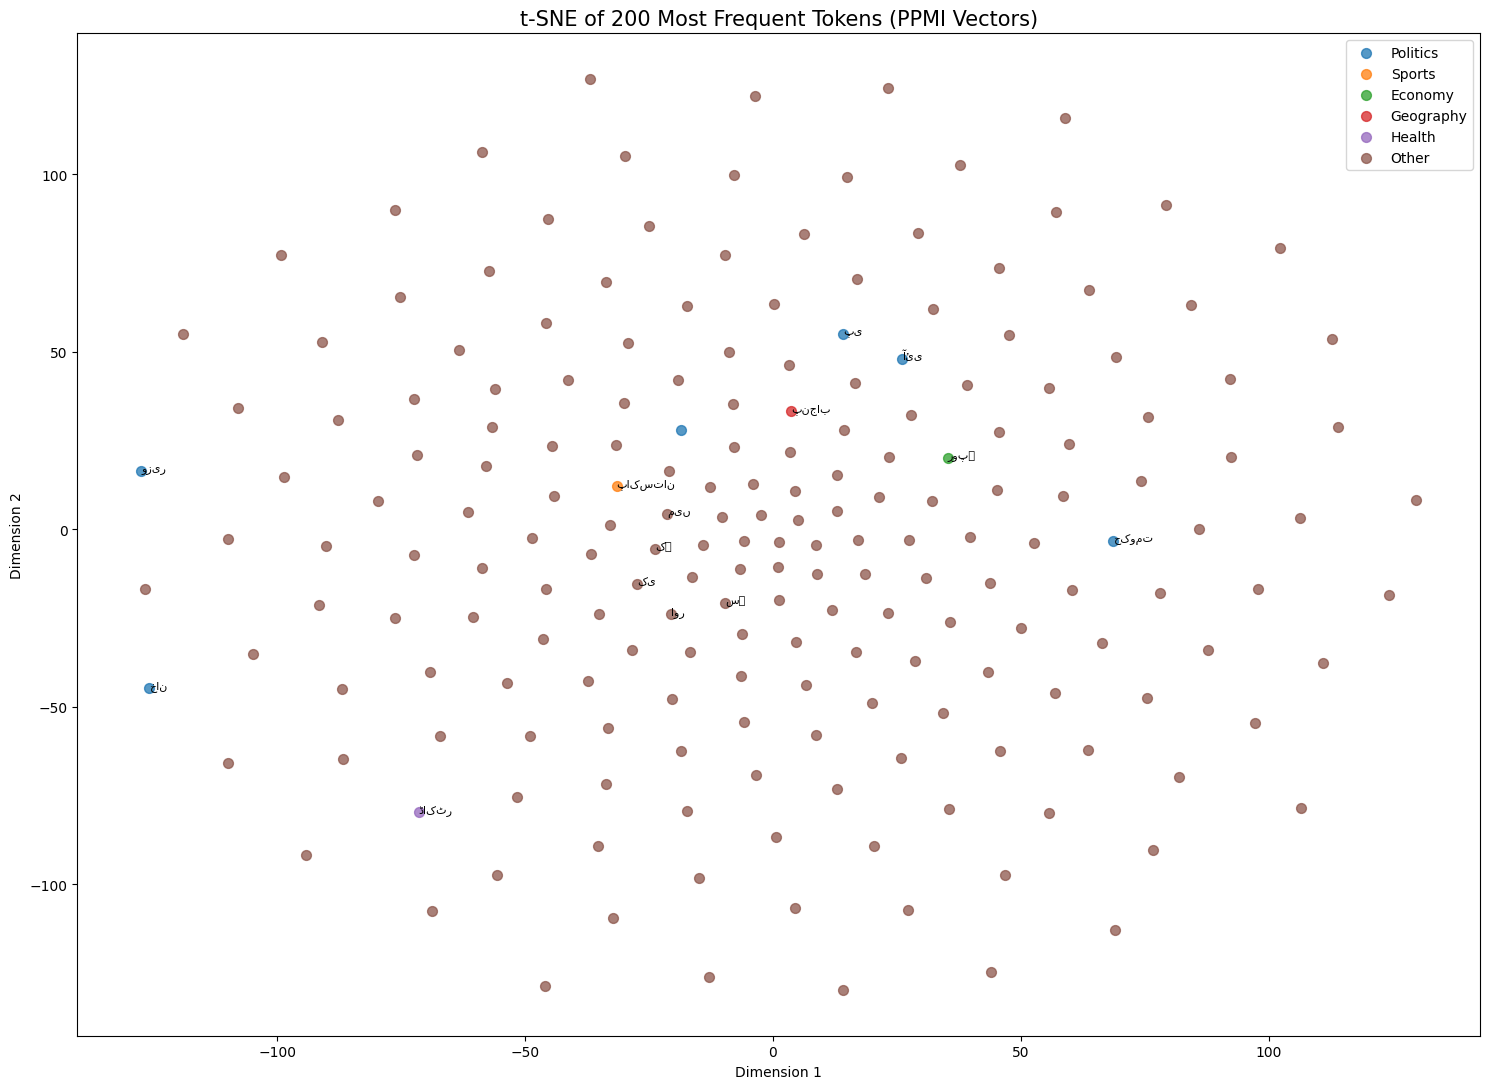

Saved → embeddings/tsne_ppmi.png


In [11]:
# Semantic categories for Urdu news corpus

SEMANTIC_GROUPS = {
    'Politics': [
        'حکومت','وزیراعظم','وزیر','پارلیمان','پی','ٹی','آئی',
        'عمران','خان','فوج','الیکشن','سیاسی'
    ],

    'Sports': [
        'کرکٹ','میچ','ٹیم','کھلاڑی','وکٹ','رن','پاکستان'
    ],

    'Economy': [
        'روپے','معیشت','بینک','قیمت','حصص','کمپنی','سرمایہ'
    ],

    'Geography': [
        'پاکستان','لاہور','کراچی','اسلام','آباد','پنجاب','بلوچستان'
    ],

    'Health': [
        'ہسپتال','صحت','مریض','ویکسین','ڈاکٹر'
    ]
}


def get_category(word):
    for cat, words in SEMANTIC_GROUPS.items():
        if word in words:
            return cat
    return 'Other'


labels = [get_category(w) for w in top_words]

# Run TSNE
tsne = TSNE(
    n_components=2,
    random_state=SEED,
    perplexity=30,
    max_iter=1000
)

coords = tsne.fit_transform(top_vecs)


# Plot
all_cats = list(SEMANTIC_GROUPS.keys()) + ['Other']
colors   = plt.cm.tab10.colors
cat2col  = {cat: colors[i] for i, cat in enumerate(all_cats)}

plt.figure(figsize=(15, 11))

for cat in all_cats:

    idxs = [i for i, lab in enumerate(labels) if lab == cat]

    plt.scatter(
        coords[idxs, 0],
        coords[idxs, 1],
        label=cat,
        alpha=0.75,
        s=50
    )

    # annotate only first 5 words
    for i in idxs[:5]:
        plt.annotate(
            top_words[i],
            (coords[i,0], coords[i,1]),
            fontsize=8
        )

plt.title('t-SNE of 200 Most Frequent Tokens (PPMI Vectors)', fontsize=15)
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend()
plt.tight_layout()

plt.savefig('embeddings/tsne_ppmi.png', dpi=150)
plt.show()

print('Saved → embeddings/tsne_ppmi.png')

In [13]:
# STEP 4 — TOP-5 NEAREST NEIGHBOURS

QUERY_WORDS = [
    'پاکستان',
    'حکومت',
    'عمران',
    'فوج',
    'روپے',
    'کمپنی',
    'کرکٹ',
    'میچ',
    'صحت',
    'لاہور'
]

print('\n' + '='*80)
print('TOP-5 NEAREST NEIGHBOURS (COSINE SIMILARITY)')
print('='*80)

for q in QUERY_WORDS:

    nbrs = nearest_neighbours(
        q,
        ppmi,
        word2idx,
        idx2word,
        top_n=5
    )

    print(f'\n[{q}]')

    for word, sim in nbrs:
        print(f'   {word:<20} {sim:.4f}')


TOP-5 NEAREST NEIGHBOURS (COSINE SIMILARITY)

[پاکستان]
   کے                   0.2320
   انڈیا                0.2181
   میں                  0.2015
   اور                  0.1861
   نے                   0.1789

[حکومت]
   صوبائی               0.1840
   نے                   0.1782
   کے                   0.1731
   کی                   0.1672
   پاکستان              0.1664

[عمران]
   خان                  0.3937
   صفدر                 0.2051
   فاروق                0.1979
   پمز                  0.1545
   معائنہ               0.1539

[فوج]
   ایرانی               0.1921
   سپاہیوں              0.1741
   پاکستانی             0.1711
   فوجی                 0.1579
   انڈین                0.1558

[روپے]
   ارب                  0.4458
   لاکھ                 0.4339
   ہزار                 0.3433
   کروڑ                 0.3356
   رقم                  0.2696

[کمپنی]
   فرٹیلائزر            0.2334
   لمیٹڈ                0.2094
   سٹاک                 0.1766
   کمپنیوں              0.1756
  

In [14]:
# EXTRA SAVE FOR PART 2.2 EVALUATION (CPU OPTIMIZED)
#
# Needed later for:
# C1 = PPMI baseline
# nearest neighbours
# analogies
# MRR evaluation

print("="*80)
print("Preparing PPMI vectors for future evaluation...")
print("="*80)

# Normalize rows once only (VERY IMPORTANT for fast cosine later)
ppmi_norm = ppmi.copy()

row_norms = np.linalg.norm(ppmi_norm, axis=1, keepdims=True) + 1e-9
ppmi_norm = ppmi_norm / row_norms

# Save normalized version
np.save("embeddings/ppmi_norm.npy", ppmi_norm)

# Save vocab reverse mapping
with open("embeddings/idx2word.json", "w", encoding="utf-8") as f:
    json.dump(idx2word, f, ensure_ascii=False)

print("Saved → embeddings/ppmi_norm.npy")
print("Saved → embeddings/idx2word.json")
print("Ready for Part 2.2")

Preparing PPMI vectors for future evaluation...
Saved → embeddings/ppmi_norm.npy
Saved → embeddings/idx2word.json
Ready for Part 2.2


###  PART 2.1 — SKIP-GRAM WORD2VEC

In [16]:
K_WINDOW = 5
K_NEG    = 10
EMB_DIM  = 100
BATCH    = 512
EPOCHS   = 5
LR      = 0.001

# STEP 1 — BUILD NOISE DISTRIBUTION
def build_noise_distribution(word2idx, freq_counter, vocab_size):

    counts = np.zeros(vocab_size, dtype=np.float64)

    for word, idx in word2idx.items():
        counts[idx] = freq_counter.get(word, 1) ** 0.75

    counts[word2idx['<PAD>']] = 0

    probs = counts / counts.sum()
    return probs.astype(np.float32)


noise_dist = build_noise_distribution(word2idx, freq_counter, VOCAB_SIZE)

print("Noise distribution ready.")


# STEP 2 — GENERATE TRAINING PAIRS

def generate_skipgram_pairs(sentences, word2idx, k=5):

    pairs = []
    unk = word2idx['<UNK>']

    for sent in sentences:

        ids = [word2idx.get(tok, unk) for tok in sent]

        for i, center in enumerate(ids):

            left  = max(0, i-k)
            right = min(len(ids), i+k+1)

            for j in range(left, right):
                if i != j:
                    pairs.append((center, ids[j]))

    return np.array(pairs, dtype=np.int32)


print("Generating pairs...")
pairs_clean = generate_skipgram_pairs(sentences_clean, word2idx, K_WINDOW)

print(f"Total pairs: {len(pairs_clean):,}")

# STEP 3 — DATASET

class SkipGramDataset(Dataset):

    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):

        c = self.pairs[idx,0]
        o = self.pairs[idx,1]

        return torch.tensor(c), torch.tensor(o)


dataset = SkipGramDataset(pairs_clean)

loader = DataLoader(
    dataset,
    batch_size=BATCH,
    shuffle=True,
    num_workers=0,
    drop_last=True
)


Noise distribution ready.
Generating pairs...
Total pairs: 4,290,474


In [17]:
# STEP 4 — MODEL
class SkipGram(nn.Module):

    def __init__(self, vocab_size, dim):

        super().__init__()

        self.V = nn.Embedding(vocab_size, dim, padding_idx=0)
        self.U = nn.Embedding(vocab_size, dim, padding_idx=0)

        nn.init.uniform_(self.V.weight, -0.5/dim, 0.5/dim)
        nn.init.uniform_(self.U.weight, -0.5/dim, 0.5/dim)

    def forward(self, center_ids, pos_ids, neg_ids):

        v = self.V(center_ids)          # (B,d)
        u_pos = self.U(pos_ids)        # (B,d)
        u_neg = self.U(neg_ids)        # (B,K,d)

        # Positive score
        pos_score = torch.sum(v * u_pos, dim=1)
        pos_loss  = F.logsigmoid(pos_score)

        # Negative score
        neg_score = torch.bmm(u_neg, v.unsqueeze(2)).squeeze(2)
        neg_loss  = F.logsigmoid(-neg_score).sum(dim=1)

        loss = -(pos_loss + neg_loss).mean()

        return loss


model = SkipGram(VOCAB_SIZE, EMB_DIM).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)

print(model)


SkipGram(
  (V): Embedding(10002, 100, padding_idx=0)
  (U): Embedding(10002, 100, padding_idx=0)
)


In [18]:
# STEP 5 — FAST NEGATIVE SAMPLING

NEG_TABLE_SIZE = 5_000_000

print("Preparing negative sampling table...")

neg_table = np.random.choice(
    np.arange(VOCAB_SIZE),
    size=NEG_TABLE_SIZE,
    p=noise_dist
)

neg_ptr = 0


def sample_negative_batch(batch_size, K):

    global neg_ptr

    total_needed = batch_size * K

    if neg_ptr + total_needed >= NEG_TABLE_SIZE:
        neg_ptr = 0

    vals = neg_table[neg_ptr:neg_ptr+total_needed]
    neg_ptr += total_needed

    return vals.reshape(batch_size, K)

Preparing negative sampling table...


In [19]:
# STEP 6 — TRAINING

loss_history = []
step = 0

print("="*80)
print("TRAINING STARTED")
print("="*80)

for epoch in range(1, EPOCHS+1):

    epoch_loss = 0
    count = 0

    for center_ids, pos_ids in loader:

        B = center_ids.size(0)

        neg_ids = sample_negative_batch(B, K_NEG)

        center_ids = center_ids.long().to(DEVICE)
        pos_ids    = pos_ids.long().to(DEVICE)
        neg_ids    = torch.tensor(neg_ids).long().to(DEVICE)

        optimizer.zero_grad()

        loss = model(center_ids, pos_ids, neg_ids)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        count += 1
        step += 1

        if step % 200 == 0:
            avg = epoch_loss / count
            print(f"Epoch {epoch} | Step {step} | Loss {avg:.4f}")
            loss_history.append(avg)

    print(f"Epoch {epoch} Completed | Avg Loss = {epoch_loss/count:.4f}")

TRAINING STARTED
Epoch 1 | Step 200 | Loss 5.9799
Epoch 1 | Step 400 | Loss 4.9400
Epoch 1 | Step 600 | Loss 4.4639
Epoch 1 | Step 800 | Loss 4.1855
Epoch 1 | Step 1000 | Loss 4.0016
Epoch 1 | Step 1200 | Loss 3.8694
Epoch 1 | Step 1400 | Loss 3.7703
Epoch 1 | Step 1600 | Loss 3.6922
Epoch 1 | Step 1800 | Loss 3.6291
Epoch 1 | Step 2000 | Loss 3.5766
Epoch 1 | Step 2200 | Loss 3.5319
Epoch 1 | Step 2400 | Loss 3.4931
Epoch 1 | Step 2600 | Loss 3.4590
Epoch 1 | Step 2800 | Loss 3.4292
Epoch 1 | Step 3000 | Loss 3.4027
Epoch 1 | Step 3200 | Loss 3.3793
Epoch 1 | Step 3400 | Loss 3.3581
Epoch 1 | Step 3600 | Loss 3.3389
Epoch 1 | Step 3800 | Loss 3.3216
Epoch 1 | Step 4000 | Loss 3.3054
Epoch 1 | Step 4200 | Loss 3.2906
Epoch 1 | Step 4400 | Loss 3.2770
Epoch 1 | Step 4600 | Loss 3.2644
Epoch 1 | Step 4800 | Loss 3.2528
Epoch 1 | Step 5000 | Loss 3.2420
Epoch 1 | Step 5200 | Loss 3.2318
Epoch 1 | Step 5400 | Loss 3.2223
Epoch 1 | Step 5600 | Loss 3.2133
Epoch 1 | Step 5800 | Loss 3.2048
E

In [20]:
# STEP 7 — SAVE FINAL EMBEDDINGS

with torch.no_grad():

    V = model.V.weight.cpu().numpy()
    U = model.U.weight.cpu().numpy()

final_embeddings = 0.5 * (V + U)

np.save("embeddings/embeddings_w2v.npy", final_embeddings)

print("Saved → embeddings/embeddings_w2v.npy")

Saved → embeddings/embeddings_w2v.npy


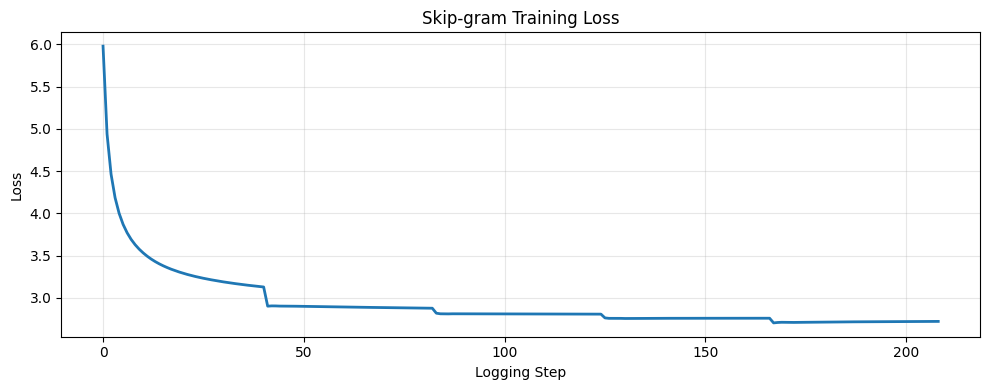

Saved → embeddings/loss_curve_w2v.png


In [21]:
# STEP 8 — LOSS CURVE
plt.figure(figsize=(10,4))
plt.plot(loss_history, linewidth=2)
plt.title("Skip-gram Training Loss")
plt.xlabel("Logging Step")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("embeddings/loss_curve_w2v.png", dpi=150)
plt.show()

print("Saved → embeddings/loss_curve_w2v.png")

In [22]:
# STEP 9 — NORMALIZED EMBEDDINGS FOR FAST SEARCH

norms = np.linalg.norm(final_embeddings, axis=1, keepdims=True) + 1e-9
emb_norm = final_embeddings / norms

np.save("embeddings/embeddings_w2v_norm.npy", emb_norm)

print("Saved → embeddings/embeddings_w2v_norm.npy")

Saved → embeddings/embeddings_w2v_norm.npy


### PART 2.2 - EVALUATION

In [24]:
# SHARED UTILITY FUNCTIONS

def cosine_sim_matrix(embeddings):
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True) + 1e-9
    return embeddings / norms


def get_nearest(word, embeddings, w2i, i2w, top_n=10):

    if word not in w2i:
        return []

    idx = w2i[word]
    vec = embeddings[idx]

    normed = cosine_sim_matrix(embeddings)
    sims = normed @ (vec / (np.linalg.norm(vec) + 1e-9))

    sims[idx] = -1

    top = np.argsort(sims)[::-1][:top_n]

    return [(i2w[i], float(sims[i])) for i in top]

In [27]:
# 1 — NEAREST NEIGHBOURS 

embeddings_c3 = final_embeddings
embeddings_c3 = np.load("embeddings/embeddings_w2v.npy")
QUERY_WORDS = [
    'pakistan', 'hukumat', 'adalat', 'maeeshat',
    'fauj', 'sehat', 'taleem', 'aabadi'
]

print("\n=== NEAREST NEIGHBOURS (C3 Skip-gram) ===\n")

for q in QUERY_WORDS:
    print(f"[{q}]")
    for w, s in get_nearest(q, embeddings_c3, word2idx, idx2word, 10):
        print(f"  {w:<20} {s:.4f}")
    print()


=== NEAREST NEIGHBOURS (C3 Skip-gram) ===

[pakistan]

[hukumat]

[adalat]

[maeeshat]

[fauj]

[sehat]

[taleem]

[aabadi]

